# Decision Tree Classification on the Iris Dataset
### Entropy, Information Gain, and Gini Index — Theory + Implementation + Visualization

This notebook walks through:
1. Loading and exploring the Iris dataset
2. Computing **Entropy**, **Gini Index**, and **Information Gain** manually
3. Training a `DecisionTreeClassifier` (with both `entropy` and `gini` criteria)
4. Visualizing the tree structure, decision boundaries, and feature importances
5. Evaluating model performance


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)


## 1. Load & Explore the Iris Dataset

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = pd.Categorical.from_codes(y, target_names)

print("Shape:", df.shape)
df.head()


Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
df['species'].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Pairplot of Iris features colored by species

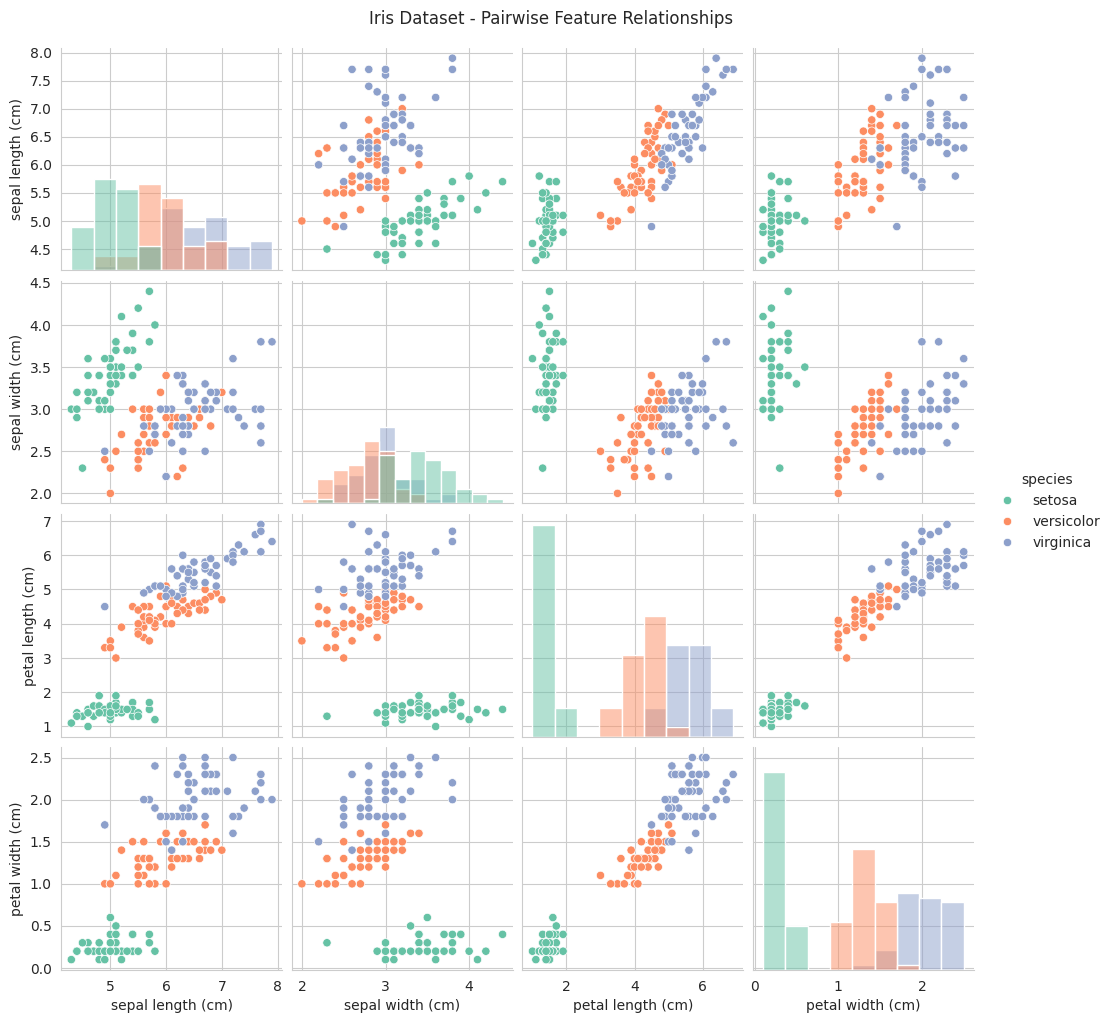

In [5]:
sns.pairplot(df, hue='species', diag_kind='hist', palette='Set2')
plt.suptitle("Iris Dataset - Pairwise Feature Relationships", y=1.02)
plt.show()


## 2. Entropy, Gini Index & Information Gain — From Scratch

For a node with class probabilities $p_1, p_2, ..., p_k$:

**Entropy:**
$$H(S) = -\sum_{i=1}^{k} p_i \log_2(p_i)$$

**Gini Index:**
$$Gini(S) = 1 - \sum_{i=1}^{k} p_i^2$$

**Information Gain** for a split of parent set $S$ into subsets $S_1, S_2, ..., S_m$:
$$IG(S, split) = H(S) - \sum_{j=1}^{m} \frac{|S_j|}{|S|} H(S_j)$$


In [6]:
def entropy(y_labels):
    """Shannon entropy of a label array."""
    counts = np.bincount(y_labels)
    probs = counts[counts > 0] / len(y_labels)
    return -np.sum(probs * np.log2(probs))

def gini_index(y_labels):
    """Gini impurity of a label array."""
    counts = np.bincount(y_labels)
    probs = counts[counts > 0] / len(y_labels)
    return 1 - np.sum(probs ** 2)

def information_gain(y_parent, y_left, y_right):
    """Information gain of splitting y_parent into y_left, y_right."""
    n = len(y_parent)
    weighted_entropy = (len(y_left) / n) * entropy(y_left) + (len(y_right) / n) * entropy(y_right)
    return entropy(y_parent) - weighted_entropy

# Whole dataset (root node) impurity
root_entropy = entropy(y)
root_gini = gini_index(y)
print(f"Root node Entropy    : {root_entropy:.4f}")
print(f"Root node Gini Index : {root_gini:.4f}")


Root node Entropy    : 1.5850
Root node Gini Index : 0.6667


### Best split search on each feature (root node) — Entropy & Gini based Information Gain

In [7]:
def best_split_for_feature(X_col, y_labels, n_thresholds=50):
    """Try candidate thresholds on a single feature and return the split
    that maximizes information gain (entropy-based) and gini gain."""
    thresholds = np.linspace(X_col.min(), X_col.max(), n_thresholds)[1:-1]
    best_ig, best_thr_ig = -1, None
    best_gini_gain, best_thr_gini = -1, None
    parent_gini = gini_index(y_labels)

    for t in thresholds:
        left_mask = X_col <= t
        right_mask = ~left_mask
        if left_mask.sum() == 0 or right_mask.sum() == 0:
            continue
        y_left, y_right = y_labels[left_mask], y_labels[right_mask]

        ig = information_gain(y_labels, y_left, y_right)
        if ig > best_ig:
            best_ig, best_thr_ig = ig, t

        n = len(y_labels)
        weighted_gini = (len(y_left)/n)*gini_index(y_left) + (len(y_right)/n)*gini_index(y_right)
        gini_gain = parent_gini - weighted_gini
        if gini_gain > best_gini_gain:
            best_gini_gain, best_thr_gini = gini_gain, t

    return best_ig, best_thr_ig, best_gini_gain, best_thr_gini

results = []
for i, fname in enumerate(feature_names):
    ig, thr_ig, gg, thr_gini = best_split_for_feature(X[:, i], y)
    results.append({
        "Feature": fname,
        "Best Threshold (IG)": round(thr_ig, 3),
        "Information Gain (Entropy)": round(ig, 4),
        "Best Threshold (Gini)": round(thr_gini, 3),
        "Gini Gain": round(gg, 4)
    })

split_df = pd.DataFrame(results).sort_values("Information Gain (Entropy)", ascending=False)
split_df


,Feature,Best Threshold (IG),Information Gain (Entropy),Best Threshold (Gini),Gini Gain
3,petal width (cm),0.639,0.9183,0.639,0.3333
2,petal length (cm),1.963,0.9183,1.963,0.3333
0,sepal length (cm),5.549,0.5572,5.402,0.2278
1,sepal width (cm),3.322,0.2831,3.322,0.1269


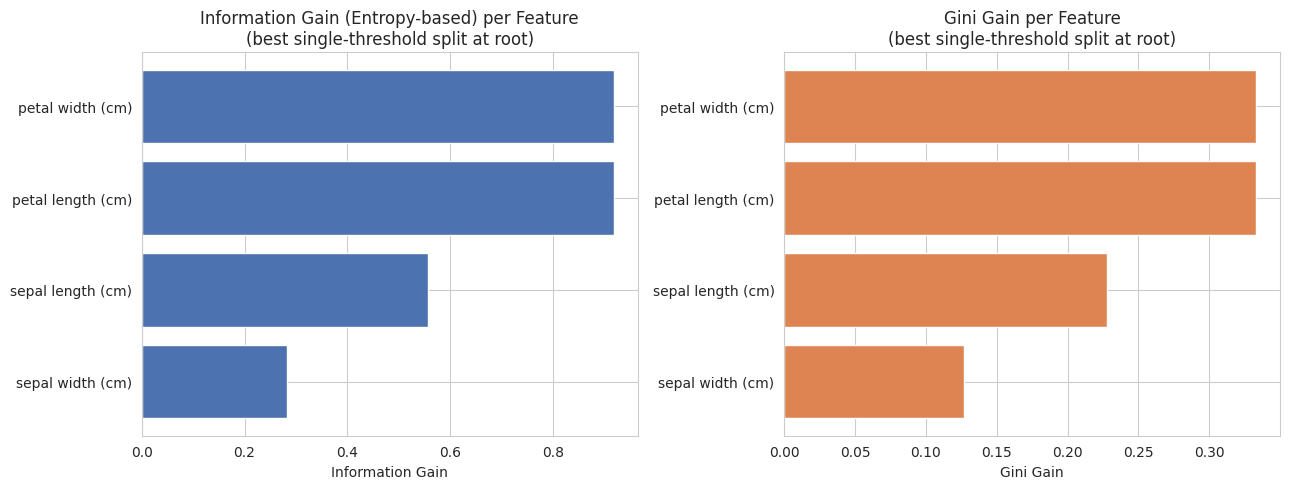

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(split_df["Feature"], split_df["Information Gain (Entropy)"], color="#4C72B0")
axes[0].set_title("Information Gain (Entropy-based) per Feature\n(best single-threshold split at root)")
axes[0].set_xlabel("Information Gain")
axes[0].invert_yaxis()

axes[1].barh(split_df["Feature"], split_df["Gini Gain"], color="#DD8452")
axes[1].set_title("Gini Gain per Feature\n(best single-threshold split at root)")
axes[1].set_xlabel("Gini Gain")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Observation:** `petal length` and `petal width` produce the highest information gain and
gini gain — meaning they are the most discriminative features for separating the three Iris
species. This matches exactly what the trained Decision Tree picks as its root/top splits below.


## 3. Train/Test Split & Train the Decision Tree Classifier

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Model using Entropy (Information Gain) criterion
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf_entropy.fit(X_train, y_train)

# Model using Gini criterion
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
clf_gini.fit(X_train, y_train)

acc_entropy = accuracy_score(y_test, clf_entropy.predict(X_test))
acc_gini = accuracy_score(y_test, clf_gini.predict(X_test))

print(f"Test Accuracy (Entropy / Information Gain criterion): {acc_entropy:.4f}")
print(f"Test Accuracy (Gini Index criterion)               : {acc_gini:.4f}")


Test Accuracy (Entropy / Information Gain criterion): 0.8889
Test Accuracy (Gini Index criterion)               : 0.8889


### Text representation of the tree (Entropy-based)

In [10]:
print(export_text(clf_entropy, feature_names=list(feature_names)))


|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- sepal length (cm) <= 6.10
|   |   |   |--- petal width (cm) <= 1.85
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.85
|   |   |   |   |--- class: 2
|   |   |--- sepal length (cm) >  6.10
|   |   |   |--- class: 2



## 4. Visualize the Decision Tree

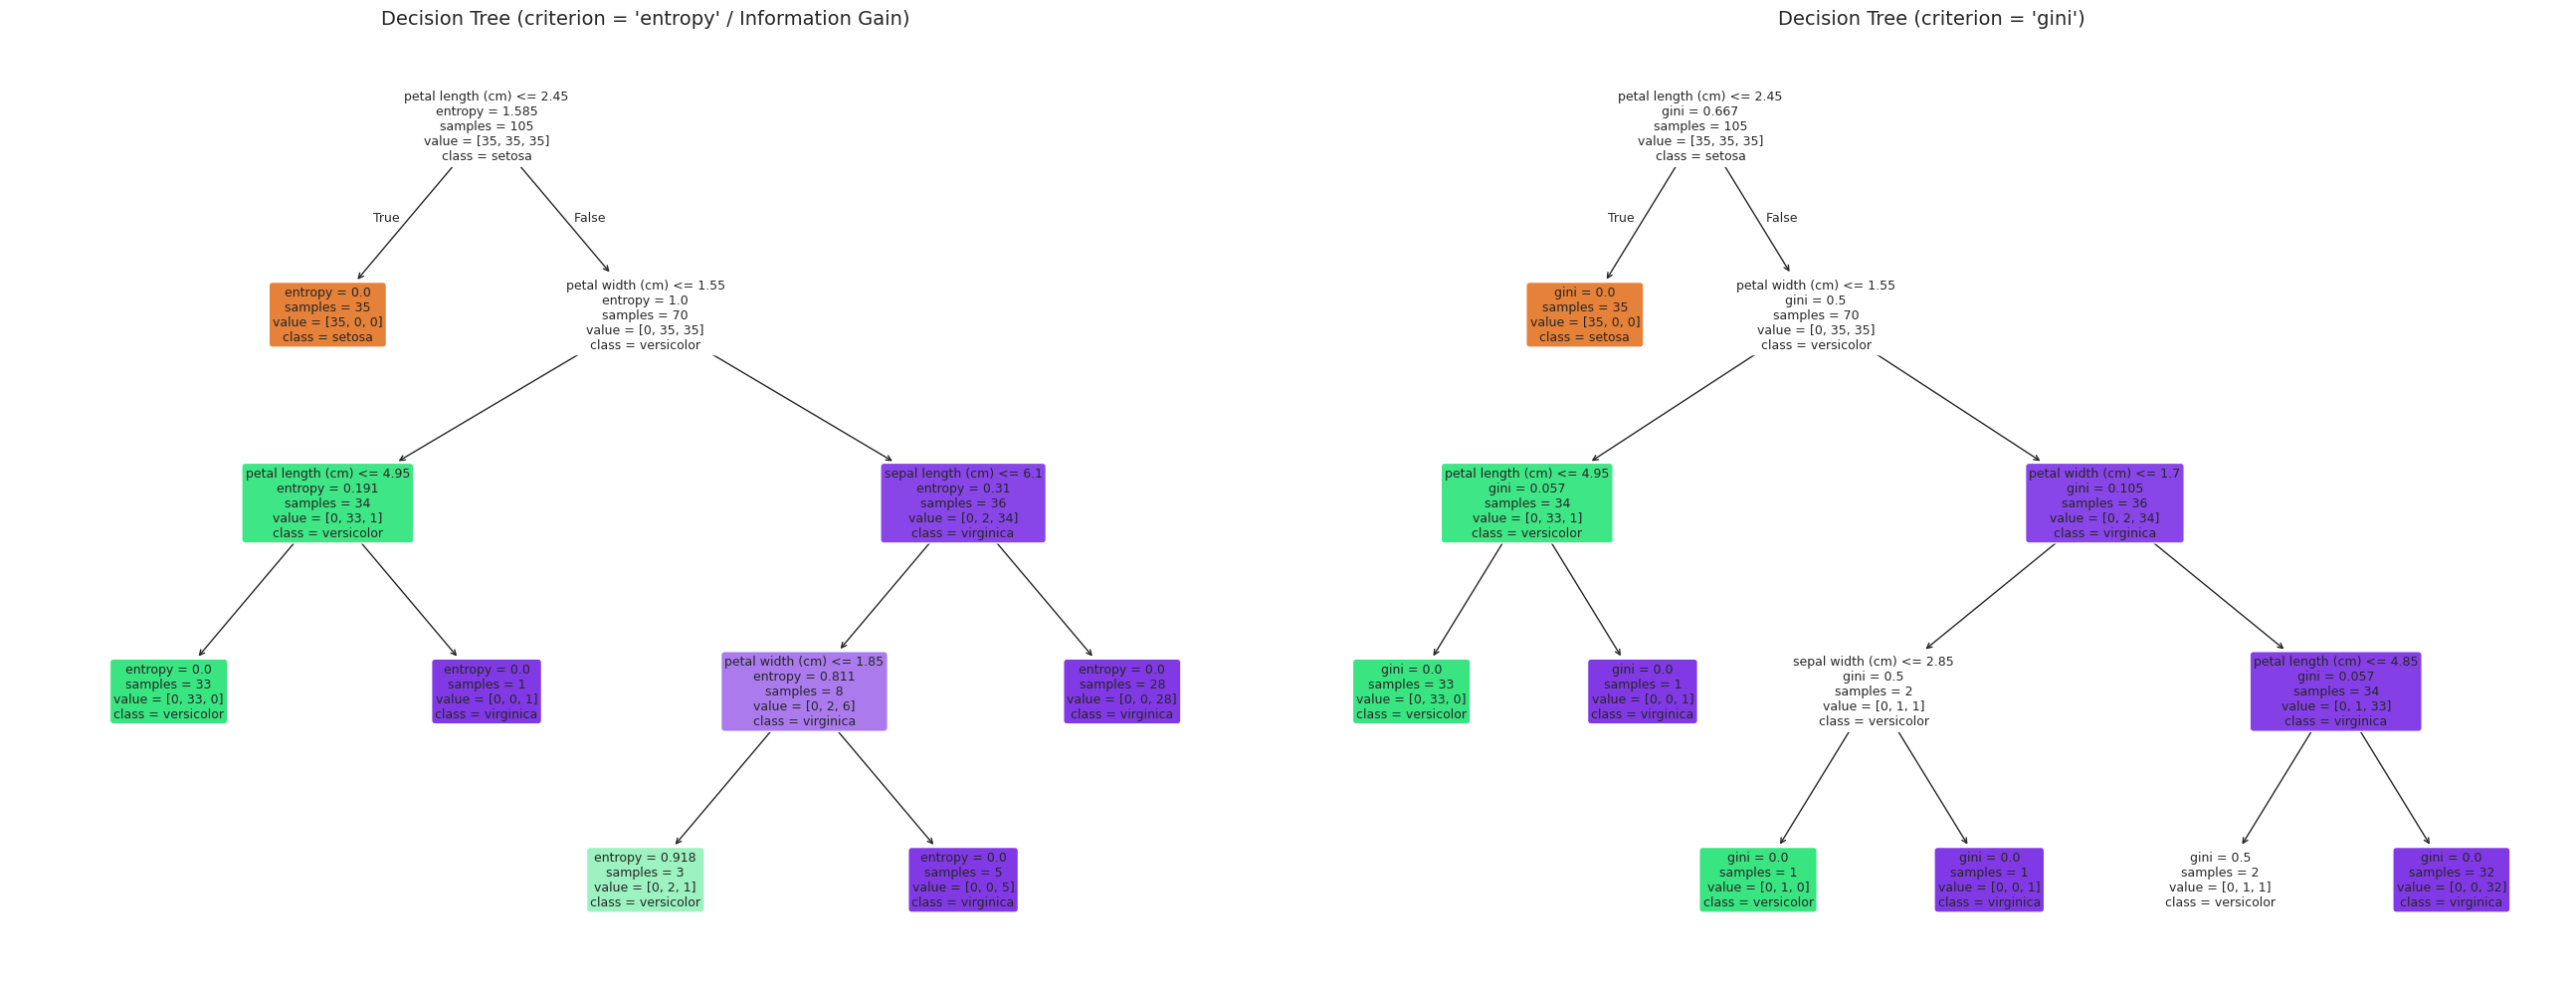

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(26, 10))

plot_tree(clf_entropy, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=9, ax=axes[0])
axes[0].set_title("Decision Tree (criterion = 'entropy' / Information Gain)", fontsize=14)

plot_tree(clf_gini, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=9, ax=axes[1])
axes[1].set_title("Decision Tree (criterion = 'gini')", fontsize=14)

plt.tight_layout()
plt.show()


## 5. Feature Importances

In [12]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Entropy-based Importance": clf_entropy.feature_importances_,
    "Gini-based Importance": clf_gini.feature_importances_
}).sort_values("Entropy-based Importance", ascending=False)

importance_df


,Feature,Entropy-based Importance,Gini-based Importance
2,petal length (cm),0.628901,0.549020
3,petal width (cm),0.342667,0.436488
0,sepal length (cm),0.028432,0.000000
1,sepal width (cm),0.000000,0.014493


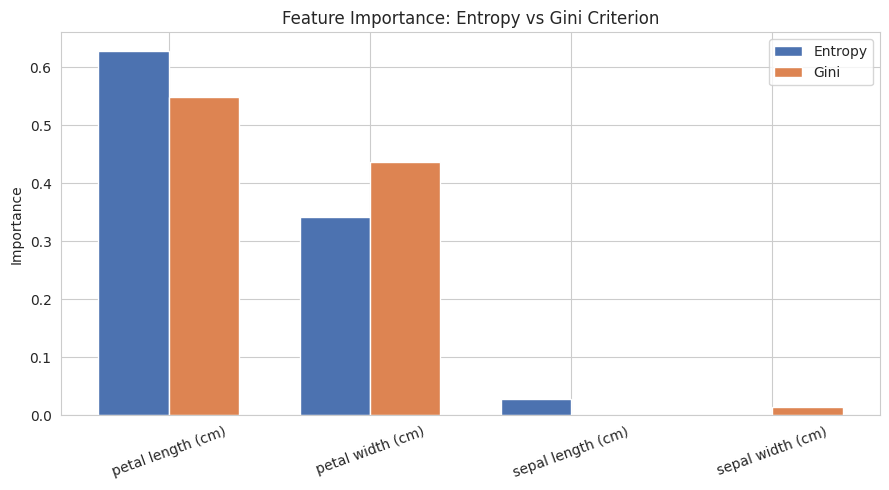

In [13]:
x = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, importance_df["Entropy-based Importance"], width, label="Entropy", color="#4C72B0")
ax.bar(x + width/2, importance_df["Gini-based Importance"], width, label="Gini", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(importance_df["Feature"], rotation=20)
ax.set_ylabel("Importance")
ax.set_title("Feature Importance: Entropy vs Gini Criterion")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Decision Boundary Visualization

Since a full 4D decision boundary can't be plotted directly, we use the two most informative
features (**petal length** and **petal width** — confirmed above by Information Gain & Gini Gain)
to draw the classification boundary lines learned by the tree.


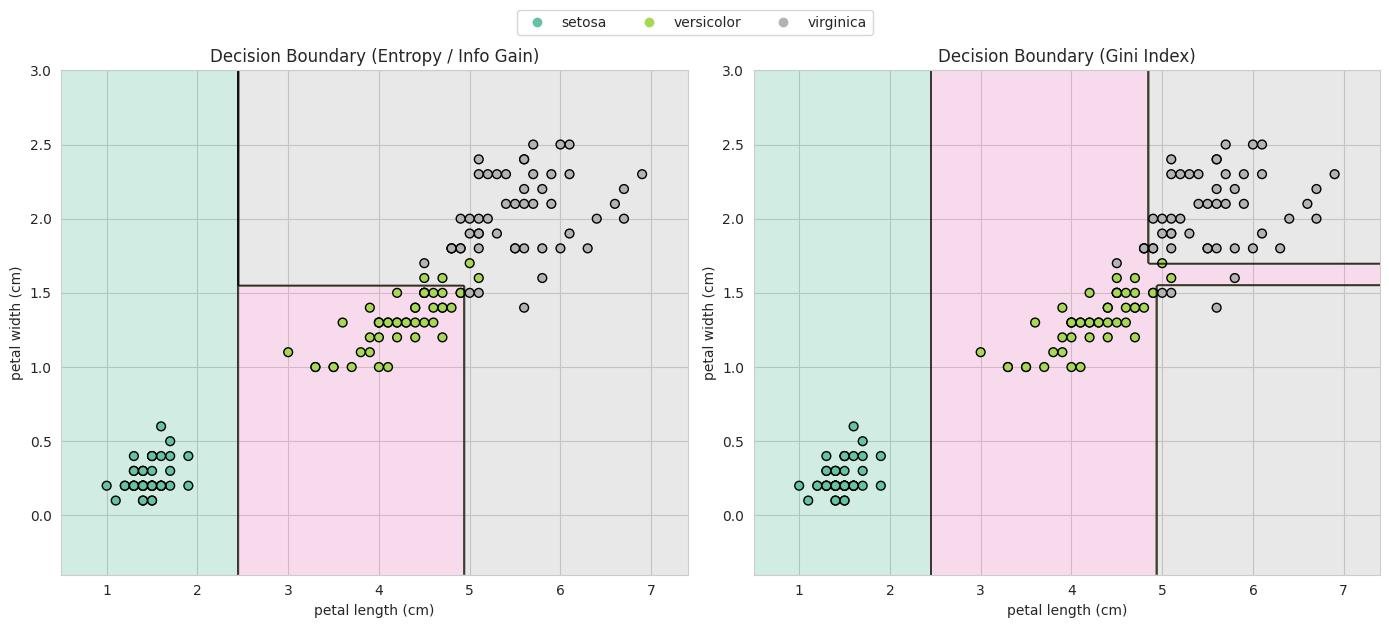

In [14]:
# Use the two most informative features: petal length (2), petal width (3)
feat_idx = [2, 3]
X2 = X[:, feat_idx]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, stratify=y
)

clf_entropy_2d = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf_entropy_2d.fit(X2_train, y2_train)

clf_gini_2d = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
clf_gini_2d.fit(X2_train, y2_train)

def plot_decision_boundary(ax, model, X2, y, title):
    x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
    y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='Set2')
    ax.contour(xx, yy, Z, colors='black', linewidths=0.6, alpha=0.6)  # classification boundary lines

    scatter = ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap='Set2', edgecolor='k', s=40)
    ax.set_xlabel(feature_names[feat_idx[0]])
    ax.set_ylabel(feature_names[feat_idx[1]])
    ax.set_title(title)
    return scatter

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_boundary(axes[0], clf_entropy_2d, X2, y, "Decision Boundary (Entropy / Info Gain)")
sc = plot_decision_boundary(axes[1], clf_gini_2d, X2, y, "Decision Boundary (Gini Index)")

handles, _ = sc.legend_elements()
fig.legend(handles, target_names, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.show()


## 7. Model Evaluation

In [15]:
y_pred = clf_entropy.predict(X_test)

print("Classification Report (Entropy-based Decision Tree):\n")
print(classification_report(y_test, y_pred, target_names=target_names))


Classification Report (Entropy-based Decision Tree):

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.81      0.87      0.84        15
   virginica       0.86      0.80      0.83        15

    accuracy                           0.89        45
   macro avg       0.89      0.89      0.89        45
weighted avg       0.89      0.89      0.89        45



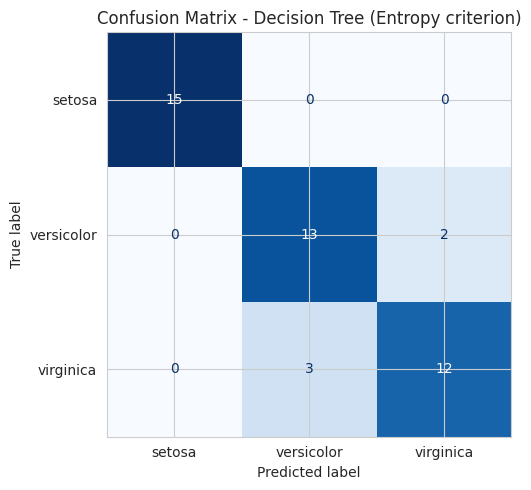

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix - Decision Tree (Entropy criterion)")
plt.tight_layout()
plt.show()


## Summary

- **Entropy** and **Gini Index** both measure node impurity; **Information Gain** (entropy-based)
  and **Gini Gain** measure how much a split reduces that impurity.
- On the Iris dataset, **petal length** and **petal width** give the highest information gain /
  gini gain, and the trained `DecisionTreeClassifier` confirms this by splitting on them first.
- Both `entropy` and `gini` criteria produce very similar, high-accuracy trees on this dataset —
  a common result since the two impurity measures are highly correlated in practice.
